NAME : Lalit Pathade


CLASS : CSAI-D

ROLL : 58

PRN : 12411458

PROBLEM STATEMENT : Assignment on Classification technique. Every year many students give the GRE exam to get admission in foreign Universities. The data set contains GRE Scores (out of 340), TOEFL Scores (out of 120), University Rating (out of 5), Statement of Purpose strength (out of 5), Letter of Recommendation strength (out of 5), Undergraduate GPA (out of 10), Research Experience (0=no, 1=yes), Admitted (0=no, 1=yes). Admitted is the target variable.

Data Set: https://www.kaggle.com/mohansacharya/graduate-admissions

The counsellor of the firm is supposed check whether the student will get an admission or not based on his/her GRE score and Academic Score. So to help the counsellor to make appropriate decisions, build a machine learning model classifier using a Decision tree to predict whether a student will get admission or not.  Apply Data pre-processing (Label Encoding, Data Transformation….) techniques if necessary.

Perform data-preparation (Train-Test Split)
Apply Machine Learning Algorithm
Evaluate Model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df= pd.read_csv("Admission_Predict.csv")

In [ ]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("Admission_Predict.csv")

# Drop Serial No.
df.drop(columns=["Serial No."], inplace=True)

# Create target variable
df["Admitted"] = df["Chance of Admit "] >= 0.75
df["Admitted"] = df["Admitted"].astype(int)

# Drop original column
df.drop(columns=["Chance of Admit "], inplace=True)

# Features and target
X = df.drop("Admitted", axis=1)
y = df["Admitted"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

Accuracy: 0.8625

Report:
               precision    recall  f1-score   support

           0       0.97      0.79      0.87        47
           1       0.76      0.97      0.85        33

    accuracy                           0.86        80
   macro avg       0.87      0.88      0.86        80
weighted avg       0.89      0.86      0.86        80



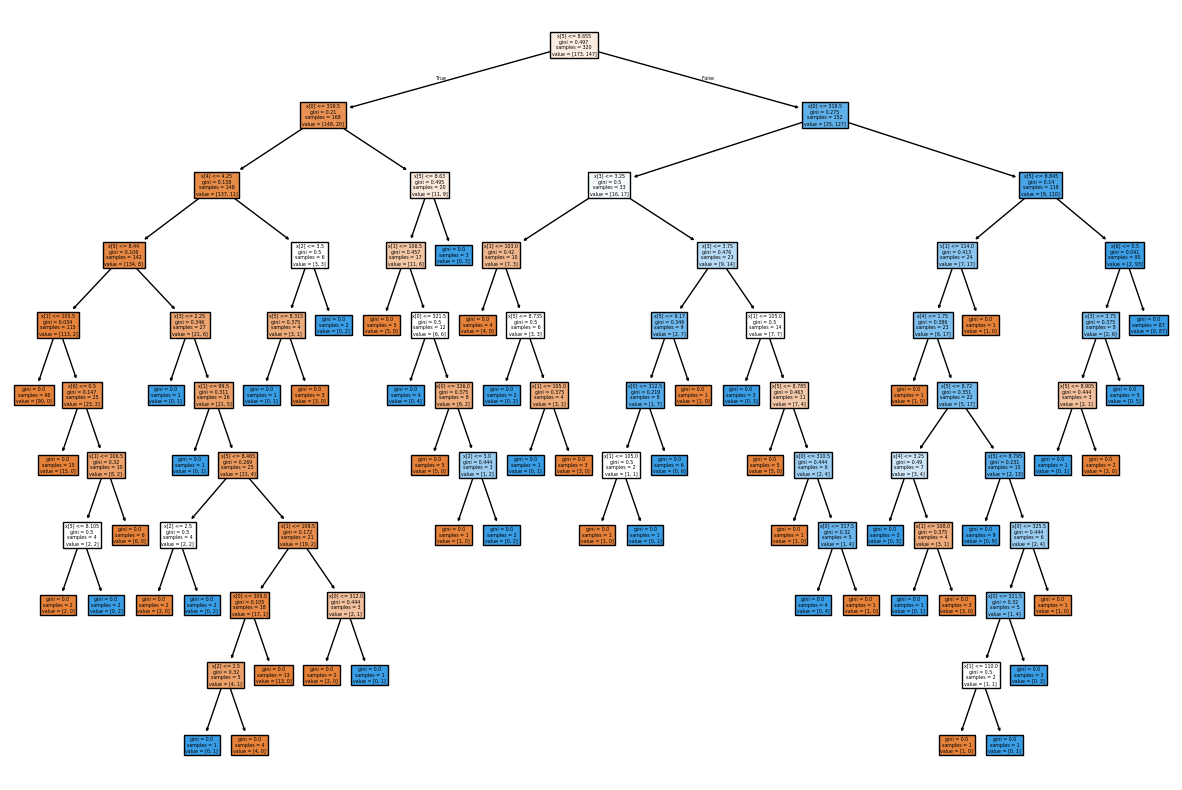

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(model, filled=True)
plt.show()